In [99]:
import sys
import os

# Add the 'src' directory to the Python path
sys.path.append(os.path.abspath("../src"))

### Configurations
TRAIN = False
PROVIDER = "openai"  # "openai" or "anthropic" or "gemini"
# EMBEDDING_PATH = f"./SavedEmbeddings/{PROVIDER}_news.pkl"

In [100]:
def chunk_text(text, tokenizer, max_tokens):
    """
    Split text into chunks, each <= max_tokens (by tokens, not words).
    Returns: a list of text chunks.
    """
    tokens = tokenizer.encode(text)
    chunks = []
    for i in range(0, len(tokens), max_tokens):
        chunk_tokens = tokens[i:i+max_tokens]
        chunk_text = tokenizer.decode(chunk_tokens)
        chunks.append(chunk_text)
    return chunks

In [101]:
def truncate_text(text, tokenizer, max_tokens):
    tokens = tokenizer.encode(text)[:max_tokens]
    return tokenizer.decode(tokens)

In [ ]:
# test turncate_test
import tiktoken

test_doc = "This is a test document. "  # create a long document
print(truncate_text(test_doc, tokenizer=tiktoken.encoding_for_model("text-embedding-ada-002"), max_tokens=2))
# expectecd output : "T"

This is


In [102]:
# select your own API key here. (Note: This specific code will not work for you unless you specified an environment variable for OPENAI_API_KEY)
import os
from dotenv import load_dotenv

load_dotenv()

if PROVIDER == "openai":
    api_key = os.environ.get('OPENAI_API_KEY')
    prompting_model = "gpt-3.5-turbo-16k"
    embedding_model = "text-embedding-ada-002"
elif PROVIDER == "gemini":
    api_key = os.environ.get('GEMINI_API_KEY')
    prompting_model = "gemini-2.0-flash-lite"
    embedding_model = "gemini-embedding-001"
elif PROVIDER == "anthropic":
    api_key = os.environ.get('ANTHROPIC_API_KEY')
    prompting_model = "claude-sonnet-4-20250514"
    embedding_model = "all-MiniLM-L6-v2"

# Dataset 


In [103]:
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
corpus = data['data']
topic_names = data.target_names  # e.g., ['alt.atheism', 'comp.graphics', ...]

filtered_corpus = []
filtered_labels = []

for doc, label in zip(corpus, data.target):
    if doc != "":
        filtered_corpus.append(doc)
        filtered_labels.append(label)
        

# Now, filtered_corpus contains only non-empty docs,
# and filtered_labels contains their corresponding ground-truth labels.
corpus = filtered_corpus
labels = filtered_labels

In [151]:
# GPT-3.5
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
topic: <topic label>
"""
# GPT-3.5
prompt_topic_desc = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, write a concise but informative description of the topic, summarizing its main themes and aspects. Make the description as wholistic as possible i.e., it describes the topic comprehensively. Use 30-35 words. 
Make sure it is in the following format: 
topic: <topic description>
"""

In [152]:
# chunking the document or truncating the documents

from bertopic import BERTopic
import tiktoken

## constants
MAX_TOKENS = 1024  # max tokens per chunk
tokenizer = tiktoken.encoding_for_model("text-embedding-ada-002")
new_corpus = []
for docs in corpus:
    # chunks = chunk_text(docs, tokenizer, MAX_TOKENS)
    chunks = truncate_text(docs, tokenizer, MAX_TOKENS)
    new_corpus.append(chunks)

type(new_corpus[0])
print(new_corpus.__len__())

18466


In [153]:
## constants
MAX_TOKENS = 1024  # max tokens per chunk
TRUNCATE = True  # whether to truncate or chunk
tokenizer = tiktoken.encoding_for_model("text-embedding-ada-002")
new_corpus = []
for docs in corpus:
    if TRUNCATE:
        chunks = truncate_text(docs, tokenizer, MAX_TOKENS)
        new_corpus.append(chunks)
    else:   
        chunks = chunk_text(docs, tokenizer, MAX_TOKENS)
        new_corpus.extend(chunks)

num_tokens_list = []
for doc in new_corpus:
    # get the number of tokens of the docs
    num_tokens = len(tokenizer.encode(doc))
    num_tokens_list.append(num_tokens)

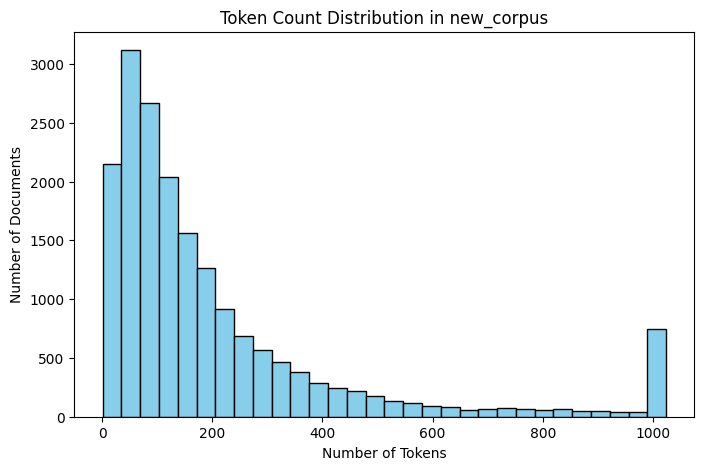

In [154]:
# plot the distribution of the number of tokens
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(num_tokens_list, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Documents')
plt.title('Token Count Distribution in new_corpus')
plt.show()

In [163]:
from bertopic import BERTopic
import tiktoken

## constants
MAX_TOKENS = 1024  # max tokens per chunk
TRUNCATE = True  # whether to truncate or chunk
tokenizer = tiktoken.encoding_for_model("text-embedding-ada-002")
new_corpus = []
for docs in corpus:
    if TRUNCATE:
        chunks = truncate_text(docs, tokenizer, MAX_TOKENS)
        new_corpus.append(chunks)
    else:   
        chunks = chunk_text(docs, tokenizer, MAX_TOKENS)
        new_corpus.extend(chunks)

print(new_corpus.__len__())

18466


In [ ]:
# Pre-calculate embeddings
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
docs_embeddings = embedding_model.encode(new_corpus, show_progress_bar=True)

# preventing stochastic behaviour for reproducibility
from umap import UMAP
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# # controlling the number of topics
from hdbscan import HDBSCAN
# number_of_clusters = 20
# min_cluster_size = int(len(new_corpus) / number_of_clusters)
hdbscan_model = HDBSCAN(min_cluster_size=40,  metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# improve default representation
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_model = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2))

# additional representations
import openai
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech
keybert_model = KeyBERTInspired() # KeyBERT
# pos_model = PartOfSpeech("en_core_web_sm") # Part-of-Speech
mmr_model = MaximalMarginalRelevance(diversity=0.3) # MMR

client = openai.OpenAI(api_key=api_key)
openai_model = OpenAI(
                client, 
                model="gpt-3.5-turbo", 
                exponential_backoff=True, 
                chat=True, 
                prompt=prompt,
                nr_repr_docs=3 # Only use 3 representative docs per topic
            )

openai_model_with_description = OpenAI(
                client,
                model="gpt-3.5-turbo",
                exponential_backoff=True,
                chat=True,
                prompt=prompt_topic_desc,
                nr_repr_docs=3
            )

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "OpenAI-Desc": openai_model_with_description,
    "MMR": mmr_model,
    # "POS": pos_model
}

### TRAINING
from bertopic import BERTopic
topic_model = BERTopic(
        # Pipeline models
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        # Hyperparameters
        top_n_words=10,
        nr_topics=21, # 21 including outlier topic -1
        verbose=True
)

topics, probs = topic_model.fit_transform(new_corpus, docs_embeddings)

In [156]:
# for topic_idx in topic_model.get_topics().keys():
#     data = topic_model.get_topic(topic_idx, full=True)
#     print(data["OpenAI"][0])
#     print(data["OpenAI-Desc"][0])

In [108]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,OpenAI,OpenAI-Desc,MMR,Representative_Docs
0,-1,5704,-1_ax_god_like_people,"[ax, god, like, people, know, just, don, does,...","[christians, religion, bible, christian, churc...",[Religious Interpretation and Philosophy],"[Religious interpretations and conflicts, mora...","[ax, god, use, think, new, edu, windows, file,...","[I posted this a couple of weeks ago, and it d..."
1,0,1911,0_drive_scsi_card_monitor,"[drive, scsi, card, monitor, ide, modem, use, ...","[scsi, hardware, ram, hard drive, disk, mother...",[Computer Hardware for Sale],[Comparison of SCSI and IDE interfaces for dri...,"[scsi, card, monitor, modem, controller, disk,...",[\nSince the Mac uses ONLY SCSI-1 for hard dri...
2,1,1851,1_game_team_year_games,"[game, team, year, games, players, season, hoc...","[nhl, hockey, puck, rangers, braves, playoffs,...",[Sports Team Evaluations],[Sports analysis covering NHL goaltenders' per...,"[games, players, season, hockey, baseball, lea...",[I thought I'd post my predicted standings sin...
3,2,1549,2_car_bike_engine_just,"[car, bike, engine, just, cars, like, miles, d...","[motorcycle, riding, bike, bikes, ride, honda,...",[Motorcycle riding tips],"[Motorcycling and car ownership experiences, i...","[engine, cars, miles, ride, speed, bmw, bikes,...",[\n\n\tHOW TO GET A VERBAL WARNING FOR 146 IN ...
4,3,929,3_medical_doctor_health_patients,"[medical, doctor, health, patients, drug, drug...","[patients, medicine, disease, infection, treat...",[Pain Management and Medical Information],[Medical advice and treatment options for vari...,"[health, patients, drugs, msg, disease, medici...",[\n\nA brain abscess is an infection deep in t...
5,4,910,4_gun_fbi_people_guns,"[gun, fbi, people, guns, batf, koresh, governm...","[second amendment, militia, guns, gun control,...",[Government Handling of Firearms JADX],"[Controversy surrounding government actions, g...","[fbi, guns, government, firearms, children, cr...",[\n...\n\nI must object to the characterizatio...
6,5,813,5_space_nasa_launch_orbit,"[space, nasa, launch, orbit, shuttle, earth, m...","[nasa gov, nasa, shuttle, space station, space...",[Becoming a NASA astronaut],[Space Exploration Overview],"[nasa, orbit, shuttle, spacecraft, solar, luna...",[SSF is up for redesign again. Let's do it ri...
7,6,767,6_windows_window_dos_file,"[windows, window, dos, file, xterm, running, u...","[window manager, openwindows, window, windows,...",[Window System Compatibility Issues],[Window Manager Configuration and Troubleshoot...,"[window, dos, xterm, application, widget, disp...",[I consider TWM-style Squeezed Titles indispen...
8,7,754,7_armenian_israel_armenians_turkish,"[armenian, israel, armenians, turkish, jews, p...","[armenians, armenian, genocide, armenia, turks...",[Armenian genocide of Muslims],[Armenian involvement in the alleged genocide ...,"[armenian, armenians, jews, genocide, turks, s...",[\n\nAnyone care to speculate on this? I'll le...
9,8,686,8_key_encryption_clipper_chip,"[key, encryption, clipper, chip, keys, governm...","[clipper chip, encryption, cryptography, crypt...",[Clipper Chip Encryption Concerns],[Clipper Chip Encryption Controversy],"[key, encryption, nsa, escrow, security, clipp...","[[An article from comp.org.eff.news, EFFector ..."


### Getting the Document Info


In [109]:
# Pre-calculate embeddings of the cropped documents
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
docs_embeddings = embedding_model.encode(new_corpus, show_progress_bar=True)

Batches:   0%|          | 0/578 [00:00<?, ?it/s]

In [110]:
# let's also reduce the dimension of the embeddings for storage efficiency
from umap import UMAP
umap_reducer = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
reduced_embeddings = umap_reducer.fit_transform(docs_embeddings)
len(reduced_embeddings)

18466

In [111]:
reduced_embeddings.shape

(18466, 5)

In [112]:
# Get document info as DataFrame
doc_info = topic_model.get_document_info(new_corpus)

# Filter out outliers (Topic == -1)
mask = doc_info["Topic"] != -1
filtered_doc_info = doc_info[mask].reset_index(drop=True)
filtered_embeddings = [docs_embeddings[i] for i, keep in enumerate(mask) if keep]
filtered_doc_info["Embedding"] = filtered_embeddings

filtered_recuded_embeddings = [reduced_embeddings[i] for i, keep in enumerate(mask) if keep]
filtered_doc_info["Reduced_Embedding"] = filtered_recuded_embeddings

# Add topic centroid embedding for each document
topic_centroids = topic_model.topic_embeddings_
filtered_doc_info["Topic_Centroid_Embedding"] = filtered_doc_info["Topic"].apply(lambda t: topic_centroids[t])

# (Optional) Add OpenAI labels if needed
openai_labels = []
openai_descs = []
for topic in filtered_doc_info["Topic"]:
    topic_data = topic_model.get_topic(topic, full=True)
    openai_label = topic_data["OpenAI"][0] if topic_data and "OpenAI" in topic_data else None
    openai_desc = topic_data["OpenAI-Desc"][0] if topic_data and "OpenAI-Desc" in topic_data else None
    openai_labels.append(openai_label[0])
    openai_descs.append(openai_desc[0])
filtered_doc_info["OpenAI"] = openai_labels
filtered_doc_info["OpenAI-Desc"] = openai_descs

# Select columns as needed
df = filtered_doc_info[["Document", "Topic", "OpenAI", "OpenAI-Desc", "Embedding", "Topic_Centroid_Embedding"]]
df.head()

,Document,Topic,OpenAI,OpenAI-Desc,Embedding,Topic_Centroid_Embedding
0,\n\nI am sure some bashers of Pens fans are pr...,1,Sports Team Evaluations,Sports analysis covering NHL goaltenders' perf...,"[0.0020780046, 0.023450432, 0.024808863, -0.01...","[-0.018468550311363473, -0.015051889947012714,..."
1,My brother is in the market for a high-perform...,0,Computer Hardware for Sale,Comparison of SCSI and IDE interfaces for driv...,"[0.050060306, 0.026980933, -0.008864836, -0.03...","[-0.019980818033218384, 0.007360474206507206, ..."
2,\n\n\n\n\tFinally you said what you dream abou...,7,Armenian genocide of Muslims,Armenian involvement in the alleged genocide o...,"[0.016404754, 0.08100051, -0.049535964, -0.008...","[-0.0010451011607396712, -0.008332298315740937..."
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,0,Computer Hardware for Sale,Comparison of SCSI and IDE interfaces for driv...,"[-0.019391475, 0.0114943655, -0.014787269, -0....","[-0.019980818033218384, 0.007360474206507206, ..."
4,\n\nAE is in Dallas...try 214/241-6060 or 214/...,17,Telephone Line Voltage Monitoring,Telephone Line Technical Issues,"[-0.04156256, -0.038990296, 0.03860057, -0.010...","[-0.025768868625164032, -0.005482123699039221,..."


## Now convet the topics from the BertTopic to **Topic Class**

### Topic Class


In [113]:
import numpy as np
from typing import List, Optional, Any

class Topic:
    def __init__(
        self,
        document_embeddings_hd: np.ndarray,
        document_embeddings_ld: Optional[np.ndarray] = None,
        centroid_hd: Optional[np.ndarray] = None,
        documents: Optional[List[str]] = None,
        topic_name: Optional[str] = None,
        topic_desc: Optional[str] = None
    ):
        assert isinstance(document_embeddings_hd, np.ndarray), "document_embeddings_hd must be a numpy array"
        if centroid_hd is not None:
            assert isinstance(centroid_hd, np.ndarray), "centroid_hd must be a numpy array"
        if documents is not None:
            assert isinstance(documents, list), "documents must be a list of strings"
        self.document_embeddings_hd = document_embeddings_hd
        self.centroid_hd = centroid_hd
        self.documents = documents or []
        self.topic_name = topic_name
        self.topic_desc = topic_desc
        if document_embeddings_ld is not None:
            assert isinstance(document_embeddings_ld, np.ndarray), "document_embeddings_ld must be a numpy array"
            self.document_embeddings_ld = document_embeddings_ld
        else:
            self.document_embeddings_ld = None

In [114]:
topic_objs = []

for topic_idx in df["Topic"].unique():
    topic_rows = df[df["Topic"] == topic_idx]
    centroid = topic_rows["Topic_Centroid_Embedding"].iloc[0]
    openai = topic_rows["OpenAI"].iloc[0]
    openai_desc = topic_rows["OpenAI-Desc"].iloc[0]
    documents = topic_rows["Document"].tolist()
    doc_embeddings = np.stack(topic_rows["Embedding"].values)  # shape: (n_docs, embedding_dim)
    topic_obj = Topic(
        document_embeddings_hd=doc_embeddings,
        centroid_hd=centroid,
        documents=documents,
        topic_name=openai,
        topic_desc=openai_desc
    )
    topic_objs.append(topic_obj)

# Example: print the first topic's name and number of documents
print(topic_objs[0].topic_name, len(topic_objs[0].documents))

Sports Team Evaluations 1851


In [115]:
# save the topic objects using pickle for later use in other notebooks
import pickle

with open("truncated_docs_topic_objs.pkl", "wb") as f:
    pickle.dump(topic_objs, f)

In [116]:
# load the truncated docs topic objects
import pickle

with open("truncated_docs_topic_objs.pkl", "rb") as f:
    topic_objs = pickle.load(f)

In [117]:
import pickle

with open("truncated_docs_topic_objs.pkl", "rb") as f:
    topic_objs = pickle.load(f)

# Check the number of topics loaded
print(f"Loaded {len(topic_objs)} topics.")

# Check the first topic's name and number of documents
print(topic_objs[0].topic_name, len(topic_objs[0].documents))

Loaded 20 topics.
Sports Team Evaluations 1851


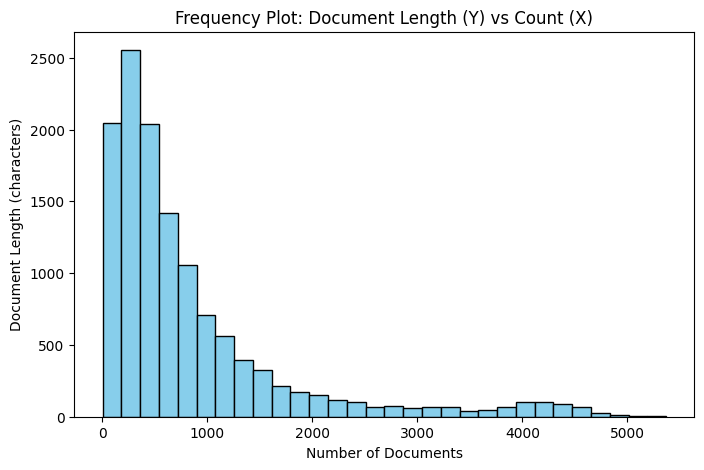

In [118]:
import matplotlib.pyplot as plt

doc_lengths = []
for topic in topic_objs:
    for doc in topic.documents:
        doc_lengths.append(len(doc))

# Plot horizontal histogram: y-axis = length, x-axis = frequency
plt.figure(figsize=(8, 5))
plt.hist(doc_lengths, bins=30, color='skyblue', edgecolor='black', orientation='vertical')
plt.ylabel('Document Length (characters)')
plt.xlabel('Number of Documents')
plt.title('Frequency Plot: Document Length (Y) vs Count (X)')
plt.show()

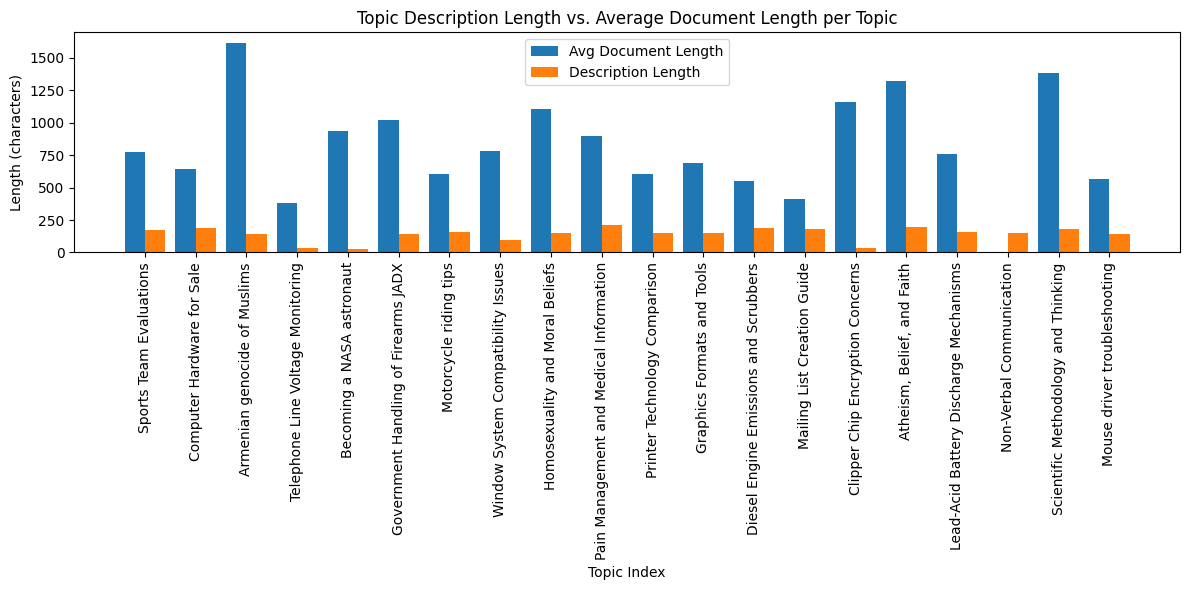

In [119]:
import matplotlib.pyplot as plt
import numpy as np

avg_doc_lengths = []
desc_lengths = []
topic_labels = []

for topic in topic_objs:
    avg_doc_lengths.append(np.mean([len(doc) for doc in topic.documents]))
    desc_lengths.append(len(topic.topic_desc) if topic.topic_desc else 0)
    topic_labels.append(topic.topic_name if topic.topic_name else "")

x = np.arange(len(topic_objs))

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, avg_doc_lengths, width=0.4, label='Avg Document Length')
plt.bar(x + 0.2, desc_lengths, width=0.4, label='Description Length')
plt.xlabel('Topic Index')
plt.ylabel('Length (characters)')
plt.title('Topic Description Length vs. Average Document Length per Topic')
plt.legend()
plt.xticks(x, topic_labels, rotation=90)
plt.tight_layout()
plt.show()

____


NOTE: Here, the prompt in the above function was from the example given by the BerTopic github. 
- Say we use the a different promt, then can we create different output? 
- TODO: [] CHECK THIS. 

In [120]:
# freq = topic_model.get_topic_info(); freq.head(5)

____

In [160]:
import pandas as pd
import numpy as np

# Dummy data
docs = [
    "Document about sports.",
    "Politics and government news.",
    "Technology advances in AI.",
    "Health and wellness tips.",
    "Travel destinations for 2025."
]

n_clusters = 3
np.random.seed(42)
random_labels = np.random.randint(1, n_clusters + 1, size=len(docs))

# Create DataFrame
df = pd.DataFrame({
    "Document": docs,
    "RandomCluster": random_labels
})

print(df)

                        Document  RandomCluster
0         Document about sports.              3
1  Politics and government news.              1
2     Technology advances in AI.              3
3      Health and wellness tips.              3
4  Travel destinations for 2025.              1


In [161]:
import pandas as pd
import numpy as np

# Dummy data
docs = [
    "Document about sports.",
    "Politics and government news.",
    "Technology advances in AI.",
    "Health and wellness tips.",
    "Travel destinations for 2025."
]

N = 5  # Number of random clusterings
C = 3  # Number of clusters

np.random.seed(42)
random_labels_matrix = np.random.randint(1, C + 1, size=(len(docs), N))

# Create DataFrame
df = pd.DataFrame({"Document": docs})
for i in range(N):
    df[f"RandomCluster_{i+1}"] = random_labels_matrix[:, i]

print(df)

                        Document  RandomCluster_1  RandomCluster_2  \
0         Document about sports.                3                1   
1  Politics and government news.                1                3   
2     Technology advances in AI.                3                3   
3      Health and wellness tips.                1                2   
4  Travel destinations for 2025.                1                1   

   RandomCluster_3  RandomCluster_4  RandomCluster_5  
0                3                3                1  
1                2                3                3  
2                1                3                2  
3                2                2                2  
4                2                2                1  
